In [678]:
import soccerdata as sd
import requests

import pandas as pd
import numpy as np

import datetime
import random
from fractions import Fraction
from tqdm import trange
from scipy.stats import poisson


## 1. 2015/16 Premier League Season Fixtures list

Pagination Contents: {"_limit":10,"_prev":null,"_next":"ODAzMTcx"}

In [679]:
base_url = 'https://sdp-prem-prod.premier-league-prod.pulselive.com/api/v2/matches'

params = {"competition": 8, "season": 2015}

all_PL_matches_15_16_season = []

for i in range(38): 
  response = requests.get(base_url, params=params)
  json_data = response.json()

  all_PL_matches_15_16_season.extend(json_data["data"])

  pagination = json_data["pagination"]
  next_page = pagination['_next']
  
  params["_next"] = next_page


fixtures = pd.DataFrame(all_PL_matches_15_16_season)
fixtures = fixtures.loc[:, ['matchWeek', 'awayTeam', 'homeTeam', 'kickoff']]

fixtures['kickoff'] = pd.to_datetime(fixtures['kickoff'])

fixtures_df = pd.DataFrame({
  "GW": fixtures['matchWeek'],
  "Date": fixtures['kickoff'],
  "kickoff_time": fixtures['kickoff'],
  "home_team": fixtures['homeTeam'].str['name'],
  "away_team": fixtures['awayTeam'].str['name']
})

fixtures_df['Date'] = fixtures_df['Date'].dt.date
fixtures_df['kickoff_time'] = fixtures_df['kickoff_time'].dt.time


fixtures_df = fixtures_df.sort_values(by=['GW', 'Date', 'kickoff_time'], ascending=True)
fixtures_df.reset_index(inplace=True, drop=True)

# len(fixtures_df) - 380 Rows 
fixtures_df.tail(10)

,GW,Date,kickoff_time,home_team,away_team
370,38,2016-05-15,15:00:00,Arsenal,Aston Villa
371,38,2016-05-15,15:00:00,Southampton,Crystal Palace
372,38,2016-05-15,15:00:00,Chelsea,Leicester City
373,38,2016-05-15,15:00:00,West Bromwich Albion,Liverpool
374,38,2016-05-15,15:00:00,Swansea City,Manchester City
375,38,2016-05-15,15:00:00,Everton,Norwich City
376,38,2016-05-15,15:00:00,Watford,Sunderland
377,38,2016-05-15,15:00:00,Newcastle United,Tottenham Hotspur
378,38,2016-05-15,15:00:00,Stoke City,West Ham United
379,38,2016-05-17,20:00:00,Manchester United,Bournemouth


In [680]:
fixtures_df['home_team'].unique()

array(['Manchester United', 'Bournemouth', 'Norwich City',
       'Leicester City', 'Everton', 'Chelsea', 'Newcastle United',
       'Arsenal', 'Stoke City', 'West Bromwich Albion', 'Aston Villa',
       'Southampton', 'West Ham United', 'Swansea City', 'Sunderland',
       'Tottenham Hotspur', 'Watford', 'Crystal Palace',
       'Manchester City', 'Liverpool'], dtype=object)

In [681]:
fixtures_df[['home_team', 'away_team']] = fixtures_df[['home_team', 'away_team']].replace({
  'Leicester City': 'Leicester',
  'Manchester City': 'Man City',
  'Manchester United': 'Man United',
  'Newcastle United': 'Newcastle',
  'Norwich City': 'Norwich',
  'Stoke City': 'Stoke',
  'Swansea City': 'Swansea',
  'Tottenham Hotspur': 'Tottenham',
  'West Bromwich Albion': 'West Brom',
  'West Ham United': 'West Ham'
})

In [682]:
set(fixtures_df['home_team'])

{'Arsenal',
 'Aston Villa',
 'Bournemouth',
 'Chelsea',
 'Crystal Palace',
 'Everton',
 'Leicester',
 'Liverpool',
 'Man City',
 'Man United',
 'Newcastle',
 'Norwich',
 'Southampton',
 'Stoke',
 'Sunderland',
 'Swansea',
 'Tottenham',
 'Watford',
 'West Brom',
 'West Ham'}

## 2. All PL Club Elo scores at the beginning of the Season

In [683]:
clubelo = sd.ClubElo(no_cache=False)
all_elo_scores = clubelo.read_by_date(date='2015-08-13')

PL_starting_elo = all_elo_scores[all_elo_scores['league'] == 'ENG-Premier League']
PL_starting_elo = PL_starting_elo.reset_index()
PL_starting_elo

[03/11/26 19:01:08] INFO     Saving cached data to /Users/fynnbackhouse/soccerdata/data/ClubElo      ]8;id=247656;file:///Users/fynnbackhouse/anaconda3/lib/python3.11/site-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=116564;file:///Users/fynnbackhouse/anaconda3/lib/python3.11/site-packages/soccerdata/_common.py#263\263]8;;\

,team,rank,country,level,elo,from,to,league
0,Man City,8.0,ENG,1,1888.496826,2015-08-11,2015-08-16,ENG-Premier League
1,Chelsea,9.0,ENG,1,1884.384277,2015-08-11,2015-08-16,ENG-Premier League
2,Arsenal,11.0,ENG,1,1829.773071,2015-08-10,2015-08-16,ENG-Premier League
3,Man United,17.0,ENG,1,1815.112915,2015-08-09,2015-08-14,ENG-Premier League
4,Liverpool,27.0,ENG,1,1760.781372,2015-08-10,2015-08-17,ENG-Premier League
5,Tottenham,35.0,ENG,1,1725.905518,2015-08-09,2015-08-15,ENG-Premier League
6,Southampton,38.0,ENG,1,1715.517456,2015-08-10,2015-08-15,ENG-Premier League
7,Everton,43.0,ENG,1,1701.660889,2015-08-09,2015-08-15,ENG-Premier League
8,Stoke,50.0,ENG,1,1690.355835,2015-08-10,2015-08-15,ENG-Premier League
9,Swansea,55.0,ENG,1,1677.186890,2015-08-09,2015-08-14,ENG-Premier League


## 3. Draw Probabilities

### 3.1 Estimating Draw Function Parameters from previous Seasons's results

In [684]:
def get_previous_season_fixtures(start_season=2014, number_of_previous_seasons=5):
  base_url = 'https://sdp-prem-prod.premier-league-prod.pulselive.com/api/v2/matches'

  params = {"competition": 8, "season": 0}

  all_matches = []

  # Current season has to be the year the season started. e.g. 2025/26 would be 2025
  current_season = start_season

  for season in trange(number_of_previous_seasons, desc='Gathering previous seasons fixtures', colour='green'):
      params['season'] = current_season

      for page in range(38):
          response = requests.get(base_url, params=params)
          json_data = response.json()

          all_matches.extend(json_data["data"])

          pagination = json_data["pagination"]
          next_page = pagination["_next"]

          params["_next"] = next_page

      current_season -= 1

  fixtures = pd.DataFrame(all_matches)
  fixtures = fixtures.loc[:, ['matchWeek', 'awayTeam', 'homeTeam', 'kickoff']]

  fixtures['kickoff'] = pd.to_datetime(fixtures['kickoff'])

  fixtures_df = pd.DataFrame({
      "GW": fixtures['matchWeek'],
      "Date": fixtures['kickoff'],
      "kickoff_time": fixtures['kickoff'],
      "home_team": fixtures['homeTeam'].str['name'],
      "away_team": fixtures['awayTeam'].str['name'], 
      'GD': fixtures['homeTeam'].str['score'] - fixtures['awayTeam'].str['score']
  })

  fixtures_df['Date'] = fixtures_df['Date'].dt.date
  fixtures_df['kickoff_time'] = fixtures_df['kickoff_time'].dt.time
  fixtures_df['elo_date'] = fixtures_df['Date'] - datetime.timedelta(days=1)

  fixtures_df = fixtures_df.sort_values(by=['GW', 'Date', 'kickoff_time'], ascending=True)
  fixtures_df = fixtures_df.reset_index(drop=True)

  return fixtures_df


In [685]:
start_season = 2014
number_of_previous_seasons = 5

previous_seasons_fixtures = get_previous_season_fixtures(start_season, number_of_previous_seasons)

Gathering previous seasons fixtures: 100%|██████████| 5/5 [00:20<00:00,  4.17s/it]


In [686]:
previous_seasons_fixtures[['home_team', 'away_team']] = previous_seasons_fixtures[['home_team', 'away_team']].replace({
    'Queens Park Rangers': 'QPR',
    'West Bromwich Albion': 'West Brom',
    'West Ham United': 'West Ham',
    'Newcastle United': 'Newcastle',
    'Wigan Athletic': 'Wigan',
    'Manchester City': 'Man City',
    'Manchester United': 'Man United',
    'Norwich City': 'Norwich',
    'Swansea City': 'Swansea',
    'Leicester City': 'Leicester',
    'Stoke City': 'Stoke',
    'Hull City': 'Hull',
    'Tottenham Hotspur': 'Tottenham',
    'Cardiff City': 'Cardiff',
    'Wolverhampton Wanderers': 'Wolves',
    'Brighton and Hove Albion': 'Brighton',
    'Sheffield Wednesday': 'Sheff Wed',
    'Blackburn Rovers': 'Blackburn',
    'Bolton Wanderers': 'Bolton',
    'Birmingham City': 'Birmingham',
    'Huddersfield Town': 'Huddersfield',
    'Luton Town': 'Luton',
    'Leeds United': 'Leeds',
    'Nottingham Forest': 'Forest',
    'Ipswich Town': 'Ipswich'
})

In [687]:
elo_differences = []
match_outcomes = []

previous_seasons_fixtures['Home Elo'] = 0.0
previous_seasons_fixtures['Away Elo'] = 0.0

home_field_advantage = 80.0

for i, match in previous_seasons_fixtures.iterrows():
  home_team = match['home_team']
  away_team = match['away_team']

  date = pd.to_datetime(match['elo_date'])
  all_elo_scores = clubelo.read_by_date(date)

  PL_elo = all_elo_scores
  home_team_elo = PL_elo.at[home_team, 'elo']
  away_team_elo = PL_elo.at[away_team, 'elo']

  effective_elo_difference = (home_team_elo + home_field_advantage) - away_team_elo
  elo_differences.append(abs(effective_elo_difference))

  GD = match['GD']
  if GD > 0: 
    match_outcomes.append(1)
  elif GD == 0: 
    match_outcomes.append(0)
  else:
    match_outcomes.append(-1)
    
  previous_seasons_fixtures.at[i, 'Home Elo'] = home_team_elo
  previous_seasons_fixtures.at[i, 'Away Elo'] = away_team_elo

In [688]:
elodiff_results_df = pd.DataFrame({
  "elo_difference": elo_differences,
  "Result": match_outcomes
})

bin_width = 50
bins = [i for i in range(-600, 601, bin_width)]
elodiff_results_df['binned_draws'] = pd.cut(elodiff_results_df['elo_difference'], bins=bins)

actual_draw_rates_by_elo_difference = elodiff_results_df.groupby('binned_draws')['Result'].apply(lambda x: (x==0).mean()).reset_index()

actual_draw_rates_by_elo_difference

,binned_draws,Result
0,"(0, 50]",0.286765
1,"(50, 100]",0.301546
2,"(100, 150]",0.301282
3,"(150, 200]",0.255319
4,"(200, 250]",0.227513
5,"(250, 300]",0.172662
6,"(300, 350]",0.076087
7,"(350, 400]",0.076923
8,"(400, 450]",0.137931
9,"(450, 500]",0.111111


In [689]:
bin_counts = elodiff_results_df.groupby('binned_draws').size()
sigma = 1/ np.sqrt(bin_counts)
sigma

binned_draws
(0, 50]       0.049507
(50, 100]     0.050767
(100, 150]    0.056614
(150, 200]    0.059549
(200, 250]    0.072739
(250, 300]    0.084819
(300, 350]    0.104257
(350, 400]    0.138675
(400, 450]    0.185695
(450, 500]    0.333333
dtype: float64

Low Draw Probability: 0.0
High Draw Probability: 0.3111
Steepness: 363.1336


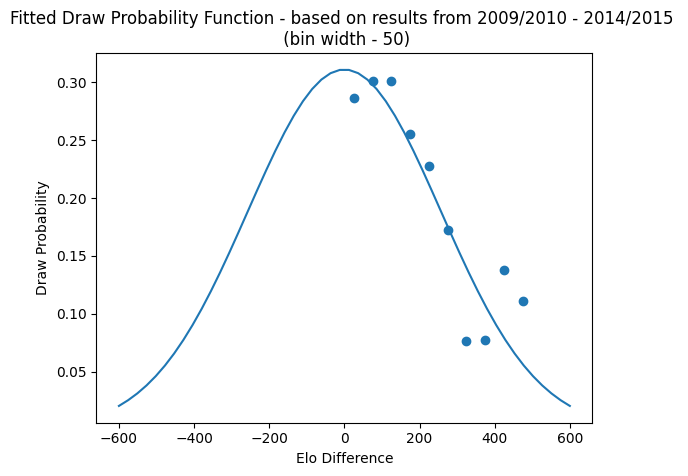

In [690]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import math

def test_function(x, l, h , s):
  return l + (h-l)*np.exp(-(x/s)**2)

x = [midpoint.mid for midpoint in actual_draw_rates_by_elo_difference['binned_draws']]
y = actual_draw_rates_by_elo_difference['Result'].values

params, param_cov = curve_fit(test_function, x, y, p0=[0.1, 0.35, 200], sigma=sigma.tolist(), bounds=([0,0,1], [1,1,1000]))

l, h, s = params


x_smooth = np.linspace(-600, 600, 50)
y_smooth = test_function(x_smooth, l, h, s)
plt.scatter(x, y)
plt.xlabel("Elo Difference")
plt.ylabel("Draw Probability")
plt.title(f"Fitted Draw Probability Function - based on results from {start_season - number_of_previous_seasons}/{start_season - number_of_previous_seasons + 1} - {start_season}/{start_season+1} \n (bin width - {bin_width})")
plt.plot(x_smooth, y_smooth)

print(f"Low Draw Probability: {np.round(l, 4)}")
print(f"High Draw Probability: {np.round(h, 4)}")
print(f"Steepness: {np.round(s, 4)}")

### 3.2 Final Draw Probability Function

In [691]:
def draw_probability(elo_difference):
  low_draw_probability = params[0]
  high_draw_probability = params[1]
  steepness = params[2]

  e = math.e
  gaussian = e**(-(elo_difference/steepness)**2)
  
  return low_draw_probability + (high_draw_probability - low_draw_probability)*gaussian

## 4. Elo Calculation Functions

In [692]:
teams = PL_starting_elo['team'].tolist()

In [693]:
def elo_win_probability(home_team_elo, away_team_elo, home_team_advantage=home_field_advantage):
  elo_difference = (home_team_elo + home_team_advantage) - away_team_elo

  draw_prob = draw_probability(elo_difference)
  win_or_lose_probability = (1 - draw_prob)

  home_team_elo_win_probability = 1 / (10**(-elo_difference/400) + 1)
  away_team_elo_win_probability = 1/ (10**(elo_difference/400) + 1)

  home_team_win_probability_adjusted_for_draws = home_team_elo_win_probability * win_or_lose_probability
  away_team_win_probability_adjusted_for_draws = away_team_elo_win_probability * win_or_lose_probability

  # total_probability = home_team_win_probability_adjusted_for_draws + draw_prob + away_team_win_probability_adjusted_for_draws

  return home_team_win_probability_adjusted_for_draws, draw_prob, away_team_win_probability_adjusted_for_draws

elo_win_probability(1701, 1888)

(0.2506719720538513, 0.2852342160773936, 0.46409381186875515)

In [694]:
average_home_goals = 1.56
average_away_goals = 1.18

In [695]:
def simulate_a_single_match(home_team_name, away_team_name, elo_df, steepness=800):
  home_team_elo = elo_df.at[home_team_name, 'elo']
  away_team_elo = elo_df.at[away_team_name, 'elo']

  home_win, draw = elo_win_probability(home_team_elo, away_team_elo, home_team_advantage=home_field_advantage)[:2]

  elo_difference = (home_team_elo + home_field_advantage) - away_team_elo


  #Below block only for dealing with tie-breakers -- ignore
  home_lambda = average_home_goals * 10 ** (elo_difference / steepness)
  away_lambda = average_away_goals * 10 ** (-elo_difference / steepness)
  home_goals = np.random.poisson(home_lambda)
  away_goals = np.random.poisson(away_lambda)
  goals = [home_goals, away_goals]
  

  random_number_between_zero_and_one = random.random()

  if random_number_between_zero_and_one < home_win:
    return 1, goals
  elif random_number_between_zero_and_one < (home_win + draw):
    return 0.5, goals 
  else: 
    return 0, goals
  
simulate_a_single_match('Man City', 'Watford', PL_starting_elo.copy().set_index('team'))

(1, [2, 1])

In [696]:
def post_result_elo_points_exchange(home_team_name, away_team_name, result, elo_df, weight=20):
  home_team_elo = elo_df.at[home_team_name, 'elo']
  away_team_elo = elo_df.at[away_team_name, 'elo']


  home_win, draw= elo_win_probability(home_team_elo, away_team_elo, home_team_advantage=home_field_advantage)[:2]

  expected_result = (1*home_win) + (0.5*draw)
  simulated_result = result

  elo_change = (simulated_result - expected_result) * weight

  elo_df.at[home_team_name, 'elo'] = (home_team_elo + elo_change)
  elo_df.at[away_team_name, 'elo'] = (away_team_elo - elo_change)

  return elo_change

post_result_elo_points_exchange('Man City', 'Watford', 0.5, PL_starting_elo.copy().set_index('team'))

-7.284041969732105

## 5. League Simulation

In [697]:
def simulate_season(fixtures_df):
  elo_df_copy = PL_starting_elo.copy().set_index('team')

  teams = PL_starting_elo['team'].tolist()

  home_team_array = fixtures_df['home_team'].to_numpy()
  away_team_array = fixtures_df['away_team'].to_numpy()

  final_table = pd.DataFrame({

    "Pos": 0, 
    "P": 0, 
    "W": 0,
    "D": 0,
    "L": 0,
    "GF": 0,
    "GA": 0
  }, index=teams)

  for home_team, away_team in zip(home_team_array, away_team_array):   
      final_table.at[home_team, 'P'] += 1
      final_table.at[away_team, 'P'] += 1

      result, goals = simulate_a_single_match(home_team, away_team, elo_df_copy)
      home_goals, away_goals = goals

      final_table.at[home_team, 'GF'] += home_goals
      final_table.at[home_team, 'GA'] += away_goals

      final_table.at[away_team, 'GF'] += away_goals
      final_table.at[away_team, 'GA'] += home_goals 

      post_result_elo_points_exchange(home_team, away_team, result, elo_df_copy)

      if result == 1: 
        final_table.at[home_team, 'W'] += 1
        final_table.at[away_team, 'L'] += 1

      elif result == 0.5: 
        final_table.at[home_team, 'D'] += 1
        final_table.at[away_team, 'D'] += 1
      else: 
        final_table.at[away_team, 'W'] += 1
        final_table.at[home_team, 'L'] += 1

  final_table['GD'] = final_table['GF'] - final_table['GA']
  final_table['Points'] = (final_table['W'] * 3) + (final_table['D'])
  final_table = final_table.sort_values(['Points', 'W', 'D', 'GD'], ascending=False).reset_index(drop=False)
  final_table['Pos'] = final_table.index + 1

  return final_table

simulate_season(fixtures_df)

,index,Pos,P,W,D,L,GF,GA,GD,Points
0,Man City,1,38,23,9,6,104,22,82,78
1,Man United,2,38,22,9,7,98,38,60,75
2,Liverpool,3,38,22,9,7,76,46,30,75
3,Arsenal,4,38,22,5,11,92,37,55,71
4,Sunderland,5,38,20,9,9,64,66,-2,69
5,Chelsea,6,38,19,10,9,108,19,89,67
6,Tottenham,7,38,16,11,11,47,43,4,59
7,Swansea,8,38,16,11,11,47,65,-18,59
8,Crystal Palace,9,38,13,16,9,45,58,-13,55
9,Bournemouth,10,38,14,10,14,34,60,-26,52


In [698]:
def monte_carlo_simulation(fixtures_df, number_of_sims):
  teams = PL_starting_elo['team'].tolist()

  league_winner_counts = pd.Series(0, index=teams)

  for i in trange(number_of_sims, desc='Simulating seasons', colour='green'):
    single_simulated_season = simulate_season(fixtures_df)
    league_winner = single_simulated_season.at[0, 'index']
    league_winner_counts[league_winner] = league_winner_counts[league_winner] + 1


  results_df = pd.DataFrame({
    "Team": teams,
    "League Winner Count": league_winner_counts,
    "League Winner Probability": league_winner_counts / number_of_sims
  })
  results_df['Fraction Chances'] = results_df['League Winner Count'].apply(lambda x: Fraction(x, number_of_sims) if x > 0 else "n/a")

  results_df = results_df.reset_index(drop=True).sort_values(by='League Winner Probability', ascending=False)
  
  return results_df

In [699]:
simulated_results = monte_carlo_simulation(fixtures_df, number_of_sims=100000)

Simulating seasons: 100%|██████████| 100000/100000 [2:07:03<00:00, 13.12it/s] 


In [700]:
simulated_results

,Team,League Winner Count,League Winner Probability,Fraction Chances
0,Man City,35386,0.35386,17693/50000
1,Chelsea,33272,0.33272,4159/12500
2,Arsenal,13107,0.13107,13107/100000
3,Man United,10138,0.10138,5069/50000
4,Liverpool,3232,0.03232,101/3125
5,Tottenham,1419,0.01419,1419/100000
6,Southampton,1088,0.01088,34/3125
7,Everton,766,0.00766,383/50000
8,Stoke,522,0.00522,261/50000
9,Swansea,386,0.00386,193/50000


In [701]:
leicester = simulated_results[simulated_results['Team'] == 'Leicester']
leicester

,Team,League Winner Count,League Winner Probability,Fraction Chances
11,Leicester,131,0.00131,131/100000
